# **Bruno Fernandes 25/26: Analysis on High-Risk High-Reward Paradox**

1. Import data

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('epl_players2526.csv', encoding='latin1')

In [ ]:
df

,player_name,team_name,position,accurateCrosses,accurateCrossesPercentage,accurateFinalThirdPasses,accurateLongBalls,accurateLongBallsPercentage,accurateOppositionHalfPasses,accurateOwnHalfPasses,...,totalDuelsWonPercentage,totalLongBalls,totalOppositionHalfPasses,totalOwnHalfPasses,totalPasses,totalShots,totwAppearances,touches,wasFouled,yellowCards
0,Declan Rice,Arsenal,M,41,28.082192,459,72,48.648649,891,687,...,61.111111,148,1054,743,1797,36,3,2327,8,2
1,Gabriel Magalhães,Arsenal,D,1,20.000000,180,63,46.323529,512,747,...,70.334928,136,622,797,1419,18,5,1747,27,3
2,Bukayo Saka,Arsenal,F,36,32.432432,300,14,36.842105,419,105,...,53.020134,38,557,126,683,63,4,1236,51,1
3,Martín Zubimendi,Arsenal,M,2,18.181818,369,48,49.484536,833,661,...,60.189573,97,985,709,1694,26,2,2026,10,4
4,Max Dowman,Arsenal,M,0,0.000000,9,0,0.000000,13,3,...,42.857143,0,14,3,17,5,0,51,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
512,Tolu Arokodare,Wolverhampton,F,0,0.000000,50,1,16.666667,102,49,...,46.825397,6,169,73,242,39,0,529,13,1
513,Fer López,Wolverhampton,M,1,25.000000,31,1,25.000000,58,17,...,31.250000,4,80,23,103,5,0,156,4,1
514,Matt Doherty,Wolverhampton,D,2,28.571429,38,12,38.709677,91,125,...,50.666667,31,125,143,268,3,0,386,5,4
515,Toti Gomes,Wolverhampton,D,3,30.000000,52,23,35.384615,175,357,...,60.810811,65,236,381,617,4,0,786,8,2


2. EDA

In [ ]:
df.columns.tolist()

['player_name',
 'team_name',
 'position',
 'accurateCrosses',
 'accurateCrossesPercentage',
 'accurateFinalThirdPasses',
 'accurateLongBalls',
 'accurateLongBallsPercentage',
 'accurateOppositionHalfPasses',
 'accurateOwnHalfPasses',
 'accuratePasses',
 'accuratePassesPercentage',
 'aerialDuelsWon',
 'aerialDuelsWonPercentage',
 'aerialLost',
 'appearances',
 'assists',
 'ballRecovery',
 'bigChancesCreated',
 'bigChancesMissed',
 'blockedShots',
 'cleanSheet',
 'clearances',
 'dispossessed',
 'dribbledPast',
 'duelLost',
 'errorLeadToGoal',
 'errorLeadToShot',
 'expectedAssists',
 'expectedGoals',
 'fouls',
 'freeKickGoal',
 'goalConversionPercentage',
 'goals',
 'goalsAssistsSum',
 'goalsConceded',
 'goalsConcededInsideTheBox',
 'goalsConcededOutsideTheBox',
 'goalsFromInsideTheBox',
 'goalsFromOutsideTheBox',
 'goalsPrevented',
 'groundDuelsWon',
 'groundDuelsWonPercentage',
 'headedGoals',
 'highClaims',
 'hitWoodwork',
 'inaccuratePasses',
 'interceptions',
 'keyPasses',
 'leftFoo

3. Extract players

In [ ]:
selected_players = [
    "Declan Rice",
    "Bruno Fernandes",
    "Rayan Cherki",
    "Dominik Szoboszlai" # Assuming 'Szobozsalai' refers to Dominik Szoboszlai
]

# Filter the DataFrame to include only the selected players
best_df = df[df["player_name"].isin(selected_players)].copy()

In [ ]:
best_df

,player_name,team_name,position,accurateCrosses,accurateCrossesPercentage,accurateFinalThirdPasses,accurateLongBalls,accurateLongBallsPercentage,accurateOppositionHalfPasses,accurateOwnHalfPasses,...,totalDuelsWonPercentage,totalLongBalls,totalOppositionHalfPasses,totalOwnHalfPasses,totalPasses,totalShots,totwAppearances,touches,wasFouled,yellowCards
0,Declan Rice,Arsenal,M,41,28.082192,459,72,48.648649,891,687,...,61.111111,148,1054,743,1797,36,3,2327,8,2
29,Rayan Cherki,Manchester City,M,19,32.758621,335,22,46.808511,580,236,...,46.938776,47,690,258,948,33,2,1311,30,1
50,Bruno Fernandes,Manchester United,M,41,30.827068,530,110,59.139785,885,446,...,47.844828,186,1105,505,1610,73,5,2143,33,3
107,Dominik Szoboszlai,Liverpool,M,53,32.515337,567,108,59.668508,962,622,...,49.771690,181,1114,699,1813,58,4,2477,26,7


3. Act 1

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# Isolate target cohort
targets = ["Bruno Fernandes", "Rayan Cherki", "Dominik Szoboszlai", "Declan Rice"]
target_df = best_df[best_df['player_name'].isin(targets)].sort_values(by='possessionLost', ascending=False)

/tmp/ipykernel_2724/3740154439.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=target_df, x='possessionLost', y='player_name', palette='Reds_r', ax=ax, edgecolor='black')


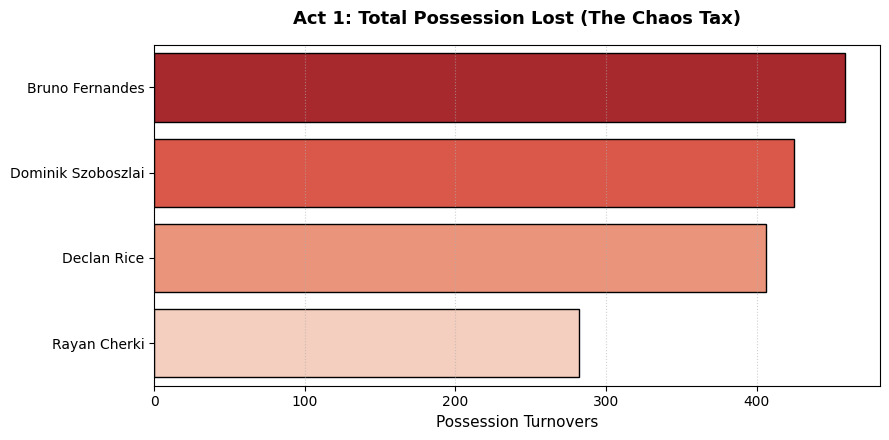

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting Act 1
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.barplot(data=target_df, x='possessionLost', y='player_name', palette='Reds_r', ax=ax, edgecolor='black')

ax.set_title('Act 1: Total Possession Lost (The Chaos Tax)', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Possession Turnovers', fontsize=11)
ax.set_ylabel('')
ax.grid(axis='x', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig('act1_chaos_tax.png', dpi=300)
plt.show()

/tmp/ipykernel_2724/3700072445.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=target_df_sorted, x='dispossessed_per90', y='player_name', palette='Blues_r', ax=ax, edgecolor='black')


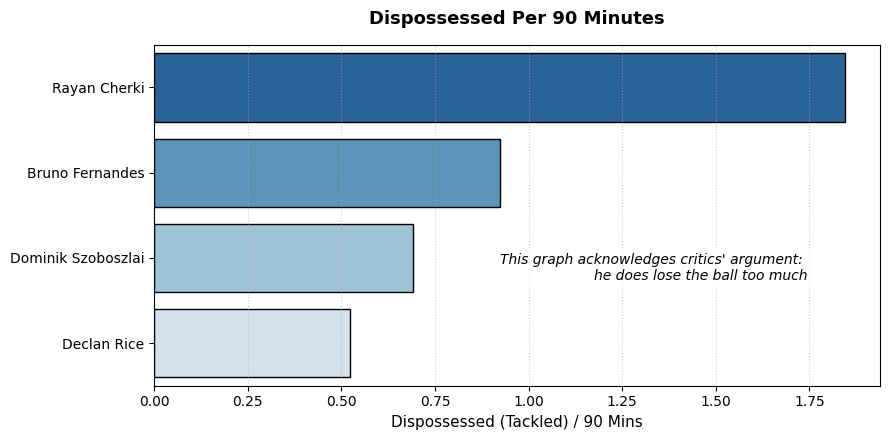

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort the DataFrame by 'dispossessed_per90' for better visualization
target_df_sorted = target_df.sort_values(by='dispossessed_per90', ascending=False)

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.barplot(data=target_df_sorted, x='dispossessed_per90', y='player_name', palette='Blues_r', ax=ax, edgecolor='black')

ax.set_title('Dispossessed Per 90 Minutes', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Dispossessed (Tackled) / 90 Mins', fontsize=11)
ax.set_ylabel('')
ax.grid(axis='x', linestyle=':', alpha=0.6)

# Add text annotation
ax.text(0.90, 0.30, "This graph acknowledges critics' argument: "
        "\nhe does lose the ball too much",
        transform=ax.transAxes, horizontalalignment='right', verticalalignment='bottom',
        fontsize=10, color='black', fontstyle='italic', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

plt.tight_layout()
plt.savefig('dispossessed_chart.png', dpi=300)
plt.show()

4. Act 2

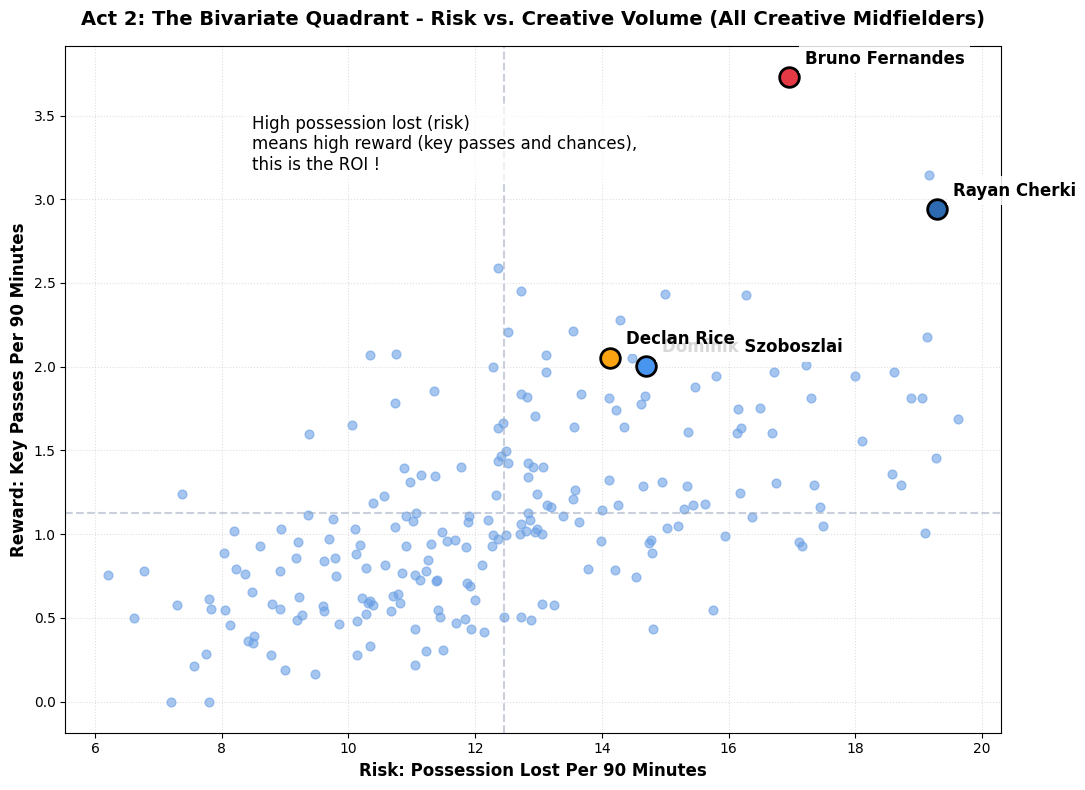

In [ ]:
# Act 2: Risk vs Reward Scatter Plot

# Filter for all creative midfielders (M and F positions, at least 5 full 90s)
creative_midfielders_df = df[(df['position'].isin(['M', 'F'])) & (df['minutesPlayed'] >= 450)].copy()

# Calculate per90 metrics for the entire creative midfield pool
creative_midfielders_df['keyPasses_per90'] = creative_midfielders_df['keyPasses'] / (creative_midfielders_df['minutesPlayed'] / 90.0)
creative_midfielders_df['possessionLost_per90'] = creative_midfielders_df['possessionLost'] / (creative_midfielders_df['minutesPlayed'] / 90.0)

fig, ax = plt.subplots(figsize=(11, 8))

# Define highlight players and their colors
highlight_players_colors = {
    "Bruno Fernandes": "#e63946", # Red
    "Dominik Szoboszlai": "#4895ef", # Darker Blue
    "Declan Rice": "#fca311",      # Orange
    "Rayan Cherki": "#2d6ab0"      # Even Darker Blue
}

highlight_names = list(highlight_players_colors.keys())

# Separate highlighted players from the rest
non_highlight_players_df = creative_midfielders_df[~creative_midfielders_df['player_name'].isin(highlight_names)]
highlight_players_df = creative_midfielders_df[creative_midfielders_df['player_name'].isin(highlight_names)]

# Plot non-highlighted players as baseline in a darker blue
ax.scatter(non_highlight_players_df['possessionLost_per90'], non_highlight_players_df['keyPasses_per90'],
           color='#6ba0e5', alpha=0.6, s=40, label='Other EPL Midfielders/Forwards')

# Highlight specific players
for name, color in highlight_players_colors.items():
    p_data = highlight_players_df[highlight_players_df['player_name'] == name]
    if not p_data.empty:
        x, y = p_data['possessionLost_per90'].values[0], p_data['keyPasses_per90'].values[0]
        ax.scatter(x, y, color=color, s=200, edgecolors='black', linewidths=2, zorder=5, label=name)
        ax.text(x + 0.25, y + 0.08, name, fontsize=12, fontweight='bold', zorder=6, bbox=dict(facecolor='white', alpha=0.85, edgecolor='none'))

# Grid structure lines (based on the entire creative midfield pool)
ax.axvline(creative_midfielders_df['possessionLost_per90'].mean(), color='#94a3b8', linestyle='--', alpha=0.5)
ax.axhline(creative_midfielders_df['keyPasses_per90'].mean(), color='#94a3b8', linestyle='--', alpha=0.5)

ax.set_xlabel('Risk: Possession Lost Per 90 Minutes', fontsize=12, fontweight='bold')
ax.set_ylabel('Reward: Key Passes Per 90 Minutes', fontsize=12, fontweight='bold')
ax.set_title('Act 2: The Bivariate Quadrant - Risk vs. Creative Volume (All Creative Midfielders)', fontsize=14, fontweight='bold', pad=15)
ax.grid(True, linestyle=':', alpha=0.4)

# Add text annotation
ax.text(0.20, 0.90, "High possession lost (risk) \nmeans high reward (key passes and chances),\nthis is the ROI !",
        transform=ax.transAxes, horizontalalignment='left', verticalalignment='top',
        fontsize=12, color='black', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.5'))

plt.tight_layout()
plt.savefig('act2_scatter_quadrant_highlighted.png', dpi=300)
plt.show()

5. Act 3:

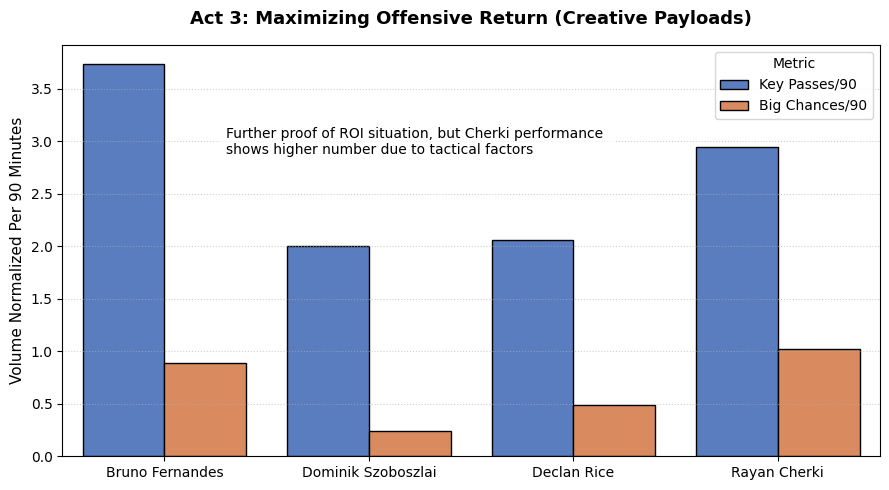

In [ ]:
# Melt and prepare shape for grouped metrics
target_df['keyPasses_per90'] = target_df['keyPasses'] / (target_df['minutesPlayed'] / 90.0)
target_df['bigChancesCreated_per90'] = target_df['bigChancesCreated'] / (target_df['minutesPlayed'] / 90.0)

melted_df = target_df.melt(id_vars='player_name', value_vars=['keyPasses_per90', 'bigChancesCreated_per90'], var_name='Metric', value_name='Value')
melted_df['Metric'] = melted_df['Metric'].replace({'keyPasses_per90': 'Key Passes/90', 'bigChancesCreated_per90': 'Big Chances/90'})

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=melted_df, x='player_name', y='Value', hue='Metric', palette='muted', ax=ax, edgecolor='black')

ax.set_title('Act 3: Maximizing Offensive Return (Creative Payloads)', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('')
ax.set_ylabel('Volume Normalized Per 90 Minutes', fontsize=11)
ax.grid(axis='y', linestyle=':', alpha=0.6)

# Add text annotation
ax.text(0.20, 0.80, "Further proof of ROI situation, but Cherki performance \nshows higher number due to tactical factors",
        transform=ax.transAxes, horizontalalignment='left', verticalalignment='top',
        fontsize=10, color='black', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.5'))

plt.tight_layout()
plt.savefig('act3_creative_payload.png', dpi=300)
plt.show()

6. Act 4:

/tmp/ipykernel_2724/1423800782.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(players, rotation=10, fontweight='semibold')


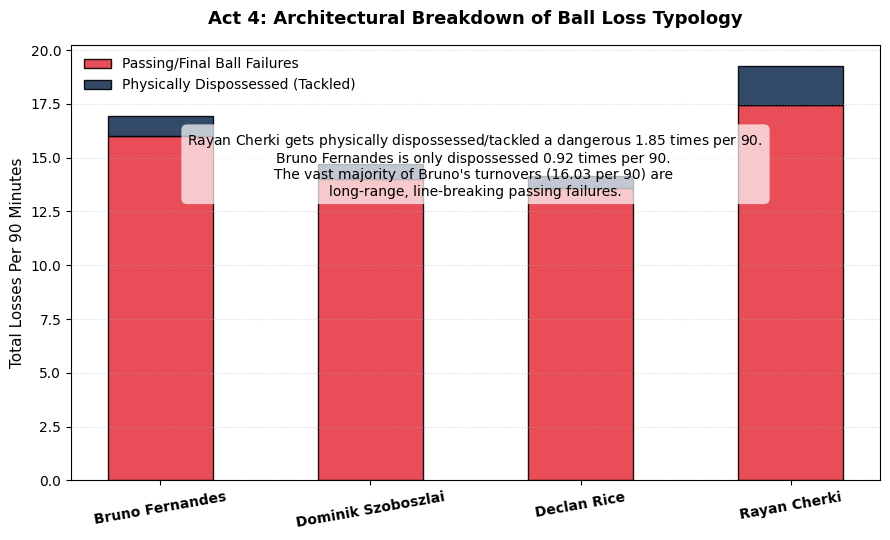

In [ ]:
# Calculate segment distributions
target_df['dispossessed_per90'] = target_df['dispossessed'] / (target_df['minutesPlayed'] / 90.0)
target_df['passingLosses_per90'] = target_df['possessionLost'] / (target_df['minutesPlayed'] / 90.0) - target_df['dispossessed_per90']

players = target_df['player_name'].tolist()
passing_loss = target_df['passingLosses_per90'].tolist()
dispossessed = target_df['dispossessed_per90'].tolist()

fig, ax = plt.subplots(figsize=(9, 5.5))

# Create stacked architectural layout
ax.bar(players, passing_loss, label='Passing/Final Ball Failures', color='#e63946', alpha=0.9, edgecolor='black', width=0.5)
ax.bar(players, dispossessed, bottom=passing_loss, label='Physically Dispossessed (Tackled)', color='#1d3557', alpha=0.9, edgecolor='black', width=0.5)

ax.set_title('Act 4: Architectural Breakdown of Ball Loss Typology', fontsize=13, fontweight='bold', pad=15)
ax.set_ylabel('Total Losses Per 90 Minutes', fontsize=11)
ax.set_xticklabels(players, rotation=10, fontweight='semibold')
ax.legend(frameon=True, facecolor='white', edgecolor='none')
ax.grid(axis='y', linestyle=':', alpha=0.5)

# Add text annotation
annotation_text = "Rayan Cherki gets physically dispossessed/tackled a dangerous $1.85$ times per $90$. \nBruno Fernandes is only dispossessed 0.92 times per 90. \nThe vast majority of Bruno's turnovers (16.03 per 90) are \nlong-range, line-breaking passing failures."
ax.text(0.50, 0.80, annotation_text,
        transform=ax.transAxes, horizontalalignment='center', verticalalignment='top',
        fontsize=10, color='black', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.4'))

plt.tight_layout()
plt.savefig('act4_loss_breakdown.png', dpi=300)
plt.show()

7. Act 5:

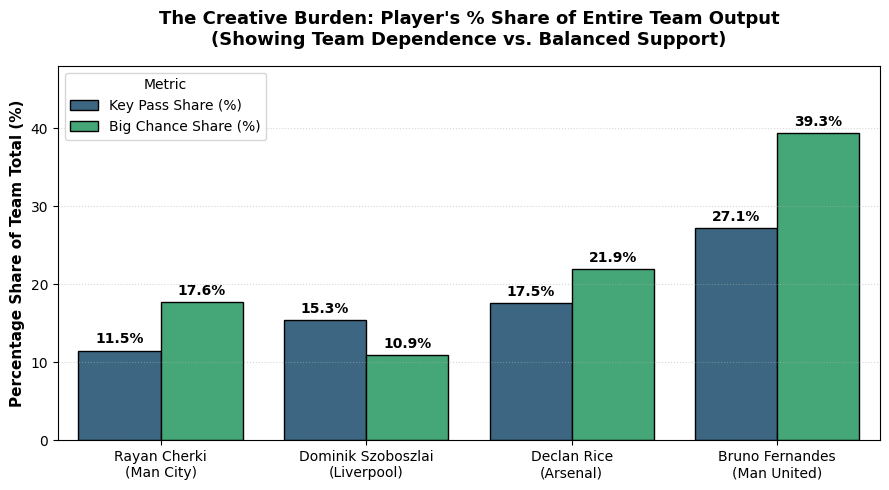

In [ ]:
# Code to generate the Creative Burden Chart
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

shares_data = pd.DataFrame({
    'Player': ['Rayan Cherki\n(Man City)', 'Dominik Szoboszlai\n(Liverpool)', 'Declan Rice\n(Arsenal)', 'Bruno Fernandes\n(Man United)'],
    'Key Pass Share (%)': [11.47, 15.34, 17.51, 27.15],
    'Big Chance Share (%)': [17.65, 10.94, 21.88, 39.34]
})

fig, ax = plt.subplots(figsize=(9, 5))
melted_shares = shares_data.melt(id_vars='Player', value_vars=['Key Pass Share (%)', 'Big Chance Share (%)'],
                                 var_name='Metric', value_name='Percentage Share')

sns.barplot(data=melted_shares, x='Player', y='Percentage Share', hue='Metric', palette='viridis', ax=ax, edgecolor='black')

# Annotate values on top of bars
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height:.1f}%', xy=(p.get_x() + p.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title("The Creative Burden: Player's % Share of Entire Team Output\n(Showing Team Dependence vs. Balanced Support)", fontsize=13, fontweight='bold', pad=15)
ax.set_ylabel('Percentage Share of Team Total (%)', fontsize=11, fontweight='bold')
ax.set_xlabel('')
ax.set_ylim(0, 48)
ax.grid(axis='y', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.savefig('tactical_creative_burden.png', dpi=300)
plt.show()

8. Act 6:

/tmp/ipykernel_2724/3136449308.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=team_env.sort_values('Team Pass Accuracy (%)'), x='Team Pass Accuracy (%)', y='Team', palette='plasma', ax=ax, edgecolor='black')


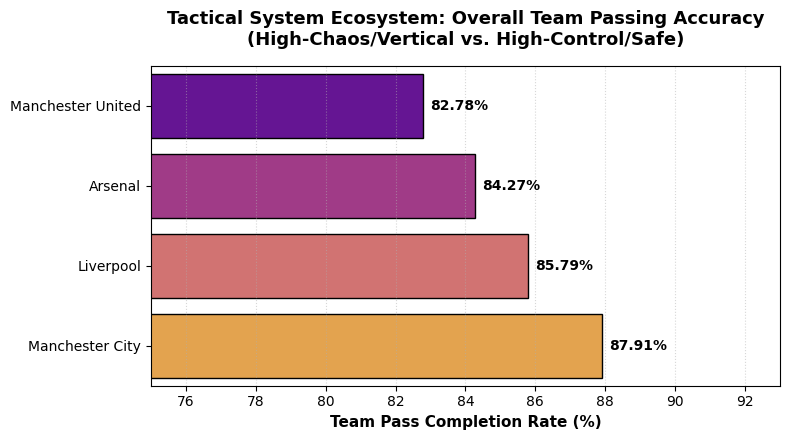

In [ ]:
# Code to generate the Team Ecosystem Chart
team_env = pd.DataFrame({
    'Team': ['Manchester United', 'Arsenal', 'Liverpool', 'Manchester City'],
    'Team Pass Accuracy (%)': [82.78, 84.27, 85.79, 87.91]
})

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(data=team_env.sort_values('Team Pass Accuracy (%)'), x='Team Pass Accuracy (%)', y='Team', palette='plasma', ax=ax, edgecolor='black')

for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{width:.2f}%', xy=(width, p.get_y() + p.get_height() / 2),
                xytext=(5, 0), textcoords="offset points", ha='left', va='center', fontsize=10, fontweight='bold')

ax.set_title("Tactical System Ecosystem: Overall Team Passing Accuracy\n(High-Chaos/Vertical vs. High-Control/Safe)", fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Team Pass Completion Rate (%)', fontsize=11, fontweight='bold')
ax.set_ylabel('')
ax.set_xlim(75, 93)
ax.grid(axis='x', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.savefig('tactical_team_ecosystem.png', dpi=300)
plt.show()